In [ ]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.append('../')

from process_fragment_miner import evaluation
from process_fragment_miner.adapters import load_event_log
import random

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
# Sample traces to estimate max trace length (O(k) vs O(n) for full scan)
# This is more efficient for large logs where scanning all traces is expensive
log = load_event_log('../data/raw/villach/processflow_export.xes')
sample_size = min(100, len(log))
sampled = random.sample(list(log), sample_size)
longest_trace = max(len(trace) for trace in sampled)
max_depth = longest_trace // 2

print(f'Log size: {len(log)}, Sample size: {sample_size}, Longest trace (sampled): {longest_trace}, max_depth: {max_depth}')

parsing log, completed traces ::   0%|          | 0/53 [00:00<?, ?it/s]

aligning log, completed variants ::   0%|          | 0/6 [00:00<?, ?it/s]

computing precision with alignments, completed variants ::   0%|          | 0/12 [00:00<?, ?it/s]

computing precision with alignments, completed variants ::   0%|          | 0/6 [00:00<?, ?it/s]

aligning log, completed variants ::   0%|          | 0/6 [00:00<?, ?it/s]

computing precision with alignments, completed variants ::   0%|          | 0/7 [00:00<?, ?it/s]

aligning log, completed variants ::   0%|          | 0/5 [00:00<?, ?it/s]

computing precision with alignments, completed variants ::   0%|          | 0/14 [00:00<?, ?it/s]

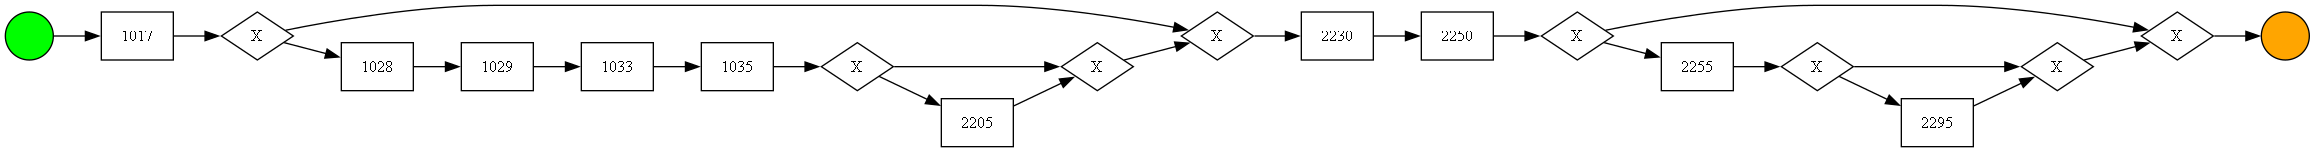

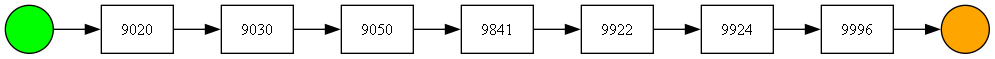

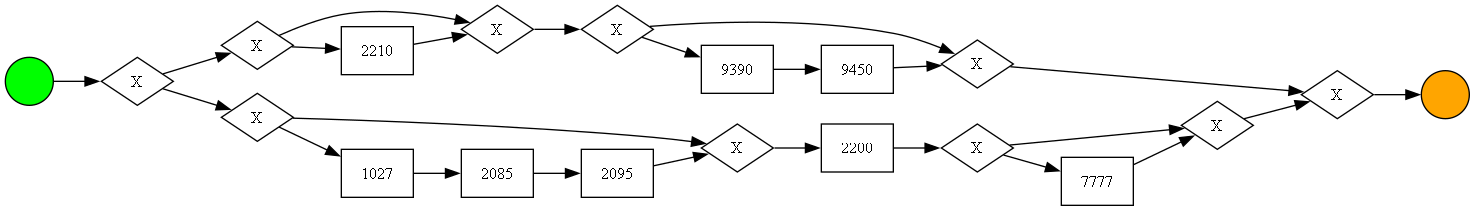

exporting log, completed traces ::   0%|          | 0/53 [00:00<?, ?it/s]

exporting log, completed traces ::   0%|          | 0/53 [00:00<?, ?it/s]

exporting log, completed traces ::   0%|          | 0/53 [00:00<?, ?it/s]

exporting log, completed traces ::   0%|          | 0/38 [00:00<?, ?it/s]

In [ ]:
evaluation('../data/raw/villach/processflow_export.xes', '../data/processed/villach/', 
           methods=['bigram'], 
           miner='split',
           max_depth=max_depth,
           dependancy_threshold=0.5
           )

# Weighted combination of frequency + heuristic scorers
# evaluation('../data/raw/villach/', '../data/processed/villach/', methods=['weighted'],
#           scorer_kwargs={'scorers': [('frequency', 0.5), ('heuristic', 0.5)]})